<a href="https://colab.research.google.com/github/ppf30/Deteccion-de-anomalias-a-partir-de-sensores-CASAS-scripted-ADL-/blob/hugo/Practica_Deteccion_Anomalias_CASAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica: Detección de anomalías a partir de sensores (CASAS scripted-ADL)
**Entornos Inteligentes · Grado en Inteligencia Artificial (UA)**

Dataset: *CASAS Smart Home - scripted activities, with and without activity errors* (Zenodo record [15712834](https://zenodo.org/records/15712834)).
Cita obligatoria: Cook, D. & Schmitter-Edgecombe, M. (2009). *Assessing the quality of activities in a smart environment*. Methods of Information in Medicine, 48(5), 480-485.

## ¿Qué escribís vosotros y qué viene ya fijado?

| Bloque | ¿Quién lo escribe? |
|---|---|
| Codificación de los CSV en el tensor fijo (carry-forward) | **Vosotros** (sección 4) |
| Al menos una arquitectura de detector (la elegís) | **Vosotros** (sección 7) |
| **Bucle de entrenamiento** (`train_model`: forward/loss/backward/optimizer) | **Vosotros** (sección 7) |
| Descargar el dataset | **FIJO** (sección 1, no se modifica) |
| Reparto de la validación: 5-fold CV **por participante** (sobre las 180 del pool), semilla 42 | **FIJO** (sección 6, no se modifica) |
| Pérdida, optimizador, hiperparámetros base, nº de épocas | **FIJOS** (secciones 6-7, no se modifican) |
| Métricas que se reportan (AUC, F1, precisión, recall, exactitud @0.5) | **FIJAS** (sección 6, no se modifican) |
| **Test conjunto de toda la clase**: 40 ejecuciones que **nadie entrena**; entreno final sobre las 180 y predicciones sobre las 40 | **FIJO** (sección 9, no se modifica) |
| Formato de la tabla de resultados | **FIJO** (sección 8) |

> Las celdas marcadas con **[FIJO - NO MODIFICAR]** no se tocan: todos los equipos usan el mismo reparto y las mismas métricas, así que los resultados son comparables. Lo que sí escribís vosotros es la **codificación del tensor** (sección 4), la **arquitectura** y el **bucle de entrenamiento** (sección 7).
>
> El **test conjunto** (40 ejecuciones sin etiqueta) es el mismo para todos y queda fuera de todo entrenamiento. Al final entrenáis una última vez sobre las 180 restantes y guardáis vuestras predicciones en `pred_test.json`: ese AUC sobre el test conjunto es la cifra que decide el ranking de la clase (sección 6 del enunciado).

## Distribución del tiempo (~8 h en clase + casa)
1. **Descargar los datos y explorar la anomalía en la señal** (~ 1,5 h): secciones 1-3.
2. **Codificar el tensor fijo** (~ 2,5 h): sección 4; la celda de validación comprueba sola vuestra codificación.
3. **Diseñar el detector y escribir vuestro bucle de entrenamiento** (~ 2 h en clase): sección 7.
4. **Evaluar con el protocolo fijo + empezar el informe** (~ 1,5 h): secciones 8-9 (la sección 9, el test conjunto, son ~ 5 min de código ejecutarse).
5. **En casa**: terminar el informe; opcional **+1**: ranking de >= 2 arquitecturas (sección 10).


## 0. Dependencias y arranque

Instala las dependencias una vez al principio. Si usáis GPU (Colab) el entrenamiento va ~20x más rápido; en CPU la validación completa (5 folds x 30 épocas) tarda ~ 1-10 min por arquitectura (los modelos son pequeños a propósito: 220 ejecuciones).

In [ ]:
!pip install -q torch numpy pandas scikit-learn matplotlib

import os, json, glob, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

# ---------------- parámetros FIJOS del protocolo ----------------
T_BINS, BIN_S = 180, 5      # rejilla: 180 bins de 5 s = 15 min
EPOCHS, BS, LR, SEED = 30, 16, 1e-3, 42
torch.manual_seed(SEED); np.random.seed(SEED)

device: cuda


## 1. Descargar el dataset **[FIJO - NO MODIFICAR]**

Descarga y descomprime los dos sets de Zenodo directamente en `data/` (`data/adl_noerror/` con 120 CSV y `data/adl_error/` con 100 CSV). Es **idempotente**: si ya están los CSV, no vuelve a descargar. Ejecutadla al principio (o solo si habéis borrado `data/`).

In [ ]:
%%bash
rm -rf temp_repo /content/data
git clone --depth 1 --filter=blob:none --no-checkout https://github.com/ppf30/Deteccion-de-anomalias-a-partir-de-sensores-CASAS-scripted-ADL-.git temp_repo
cd temp_repo
git sparse-checkout set data
git checkout
mkdir -p /content/data
cp -r data/* /content/data/
cd ..
rm -rf temp_repo
ls -la /content/data

Your branch is up to date with 'origin/main'.
total 4704
drwxr-xr-x 4 root root    4096 Oct  1 15:57 .
drwxr-xr-x 1 root root    4096 Oct  1 15:57 ..
drwxr-xr-x 2 root root    4096 Oct  1 15:57 adl_error
drwxr-xr-x 2 root root    4096 Oct  1 15:57 adl_noerror
-rw-r--r-- 1 root root   32974 Oct  1 15:57 meta.json
-rw-r--r-- 1 root root     744 Oct  1 15:57 test_files.json
-rw-r--r-- 1 root root 4752128 Oct  1 15:57 X_ref.npy
-rw-r--r-- 1 root root     348 Oct  1 15:57 Y.npy


Cloning into 'temp_repo'...


In [ ]:
import urllib.request, zipfile, os
ZENODO = "https://zenodo.org/records/15712834/files"   # record 15712834

def _count(d):
    try: return len([f for f in os.listdir(d) if f.endswith(".csv")])
    except FileNotFoundError: return 0

def download_if_missing(name, n_expected):
    out_dir = os.path.join("data", name)
    n = _count(out_dir)
    if n == n_expected:
        print(f"{name}: ya descargado ({n} csv) - se omite")
        return
    url = f"{ZENODO}/{name}.zip?download=1"
    z = os.path.join("data", name + ".zip")
    print(f"descargando {url} ...")
    urllib.request.urlretrieve(url, z)
    with zipfile.ZipFile(z) as zf:
        zf.extractall("data")
    os.remove(z)
    print(f"{name}: {_count(out_dir)} csv descargados")

os.makedirs("data", exist_ok=True)
download_if_missing("adl_noerror", 120)
download_if_missing("adl_error",   100)
print("dataset listo en data/")

descargando https://zenodo.org/records/15712834/files/adl_noerror.zip?download=1 ...
adl_noerror: 120 csv descargados
descargando https://zenodo.org/records/15712834/files/adl_error.zip?download=1 ...
adl_error: 100 csv descargados
dataset listo en data/


## 2. Los datos

220 ejecuciones, en dos sets:

* `adl_noerror` - 120 ejecuciones normales (24 por tarea).
* `adl_error` - 100 ejecuciones con un error scriptado (20 por tarea).

Cada ejecución es un CSV `pXX.tY.csv` (participante x tarea) con columnas `date, time, sensor, message`; cada fila es un evento.

| Tarea | Descripción | Error scriptado (la anomalía) |
|---|---|---|
| t1 - Llamar por teléfono | Ir al teléfono, buscar el número y llamar | Marca un número equivocado y debe volver a marcar |
| t2 - Lavarse las manos | Lavarse en el fregadero con jabón | **No cierra el grifo al terminar** |
| t3 - Cocinar | Cocinar avena siguiendo la receta | No apaga la hornilla tras cocinar |
| t4 - Comer | Lleva la comida y la medicación al comedor | No lleva el bote de medicación |
| t5 - Limpiar | Lavar los platos en el fregadero | No usa agua al lavar los platos |

La anomalía se manifiesta en la señal. Ejemplo: en t2 con error, el canal de nivel de agua (AD1-B) **no baja al final** porque el grifo se queda abierto. Esa "cola" es lo que el detector debe aprender a leer.

In [ ]:
# Tensor de REFERENCIA (solo para la validación de vuestra codificación) + etiquetas
REF = json.load(open("data/meta.json"))
X_ref = np.load("data/X_ref.npy")          # (220, 30, 180) float32
Y     = np.load("data/Y.npy")              # (220,) 0/1
print("X_ref:", X_ref.shape, X_ref.dtype, "| Y:", Y.shape,
      "| y=1 (error):", int(Y.sum()), "| y=0 (normal):", int((1-Y).sum()))
print("canales (orden FIJO, 30):", REF["channels"])

# TEST CONJUNTO de toda la clase (40 ejecuciones, SIN etiqueta; nadie entrena sobre él)
TEST_FILES = json.load(open("data/test_files.json"))["files"]
IDX_TEST = [i for i, r in enumerate(REF["runs"]) if r["file"] in TEST_FILES]
print(f"test conjunto: {len(IDX_TEST)} ejecuciones (el AUC sobre ellas decide el ranking de la clase)")

# Una ejecución cruda (con error)
df = pd.read_csv("data/adl_error/p22.t2.csv")
df.head(15)

FileNotFoundError: [Errno 2] No such file or directory: 'data/meta.json'

## 3. Paso 1 - Explorar los datos y ver la anomalía (~ 1,5 h)

Tarea: elegid **una tarea** (p. ej. t2), tomad una ejecución **normal** (p50.t2) y una **con error** (p22.t2), y dibujad la señal cruda de ambas: movimiento (PIR) y nivel de agua (AD1-B). La figura debe dejar ver por qué el error es visible en la señal.

Preguntas para el informe: ¿qué sensores intervienen en la tarea elegida? ¿En qué zona temporal (bins) se ve la anomalía? ¿Y si la anomalía es la *ausencia* de algo (p. ej. t4, no llevar la medicación)?

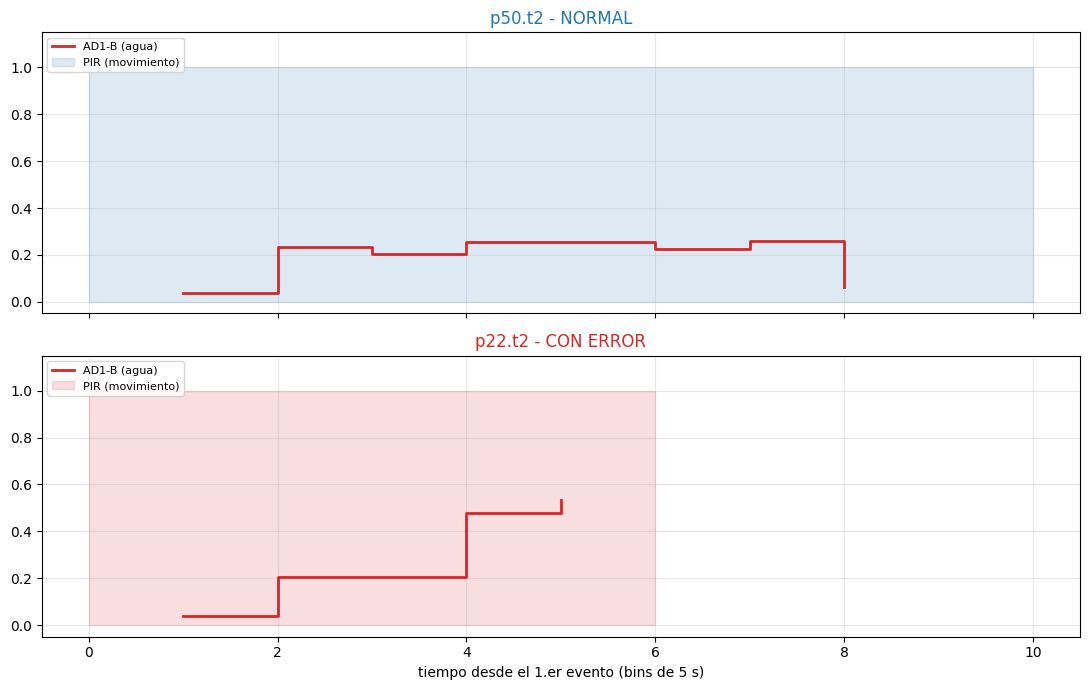

In [ ]:
def load_run(name):
    """Lee un CSV pXX.tY.csv (nombre como 'p22.t2', sin extensión) y devuelve un df ordenado
    con columnas: sensor, value (0/1 en discretos, nivel float en AD1-*), ts, t_bin."""
    for d in ("adl_error", "adl_noerror"):
        p = os.path.join("data", d, name + ".csv")
        if os.path.exists(p):
            f = p; break
    d = pd.read_csv(f)
    d["ts"] = pd.to_datetime(d["date"] + " " + d["time"], format="mixed")
    d = d.sort_values("ts").reset_index(drop=True)
    t0 = d["ts"].iloc[0]
    d["t_bin"] = ((d["ts"] - t0).dt.total_seconds() // BIN_S).astype(int)
    d["value"] = [float(m) if s.startswith("AD1") else
                  (1.0 if m in ("ON", "PRESENT", "OPEN", "START", "START_INSTRUCT") else 0.0)
                  for s, m in zip(d["sensor"], d["message"])]
    return d

def plot_pair(normal, error):
    """Dibuja la señal cruda de dos ejecuciones: PIR (área azul) + AD1-B (línea roja)."""
    fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
    for ax, (name, lab, col) in zip(axes, [(normal, "NORMAL", "tab:blue"),
                                           (error, "CON ERROR", "tab:red")]):
        d = load_run(name)
        ad = d[d["sensor"] == "AD1-B"]
        if len(ad):
            ax.step(ad["t_bin"], ad["value"], where="post", color="tab:red", lw=2, label="AD1-B (agua)")
        pir = d[d["sensor"].str.startswith("M")]
        if len(pir):
            ax.fill_between(pir["t_bin"], 1, 0, step="post", color=col, alpha=0.15, label="PIR (movimiento)")
        ax.set_title(f"{name} - {lab}", color=col)
        ax.set_ylim(-0.05, 1.15); ax.grid(alpha=0.3); ax.legend(loc="upper left", fontsize=8)
    axes[1].set_xlabel("tiempo desde el 1.er evento (bins de 5 s)")
    fig.tight_layout(); plt.show()

# Ejemplo (cambiadlo por vuestra pareja):
plot_pair("p50.t2", "p22.t2")

## 4. Paso 2 - Codificar el tensor fijo <- **vuestro código**

Cada ejecución se codifica en un tensor **(30 canales x 180 bins de 5 s)**, anclado al **primer evento**, con **carry-forward**: cada canal mantiene su último valor conocido hasta que llega un nuevo evento de ese sensor.

Reglas (las mismas que en el enunciado, sección 4):

* **Discretos** (M*, I*, D01, asterisk, E01): `1` mientras dura el estado activo (ON / PRESENT / OPEN / START..END / START_INSTRUCT..STOP_INSTRUCT), `0` en el estado contrario.
* **Analógicos** (AD1-A, AD1-B, AD1-C): el valor `message` tal cual (nivel), llevado al bin correspondiente.
* **Orden de canales FIJO** (30): el de la celda 2 (`REF["channels"]`).
* **Anclaje**: el 1.er evento de la ejecución cae en el bin 0. Los bins sin eventos mantienen el último valor conocido del canal (carry-forward); antes del primer evento de un sensor, su canal es 0.
* La normalización a [0,1] de los analógicos **la hace la celda fijada de la sección siguiente** (no la hagáis vosotros).

> El CSV de p22.t2 tiene 15 eventos en ~31 s, pero el tensor siempre mide 30 x 180. Solo 6 canales toman valores distintos de cero en esa ejecución.

Escribid `encode_run(path_csv) -> np.ndarray (30, 180)` float32.

In [ ]:
# ------------------------------------------------------------------ TODO
# VUESTRO CÓDIGO: implementad encode_run(path) -> (30, 180) float32
# - leed el CSV (date, time, sensor, message) y ordenadlo por tiempo
# - bin = floor((t - t0) / 5) con t0 = 1.er evento de la ejecución
# - carry-forward: cada canal mantiene su último valor hasta el siguiente evento
#   del mismo canal (y hasta el final si no llega ninguno)
CH = REF["channels"]                       # orden FIJO de canales
CH_IDX = {s: i for i, s in enumerate(CH)}

def encode_run(path):
    raise NotImplementedError("implementad vuestra codificación aquí")

# Ensamblado en el orden FIJO de las ejecuciones (el de REF["runs"])
FILES = [f"data/{('adl_noerror' if r['set'] == 'noerror' else 'adl_error')}/{r['file']}"
         for r in REF["runs"]]
X = np.stack([encode_run(p) for p in FILES])
print("vuestra X:", X.shape, X.dtype)

NotImplementedError: implementad vuestra codificación aquí

In [31]:
import pandas as pd

d = pd.read_csv('data/adl_noerror/p13.t3.csv')
d["ts"] = pd.to_datetime(d["date"] + " " + d["time"], format="mixed")
d = d.sort_values("ts").reset_index(drop=True)
t0 = d["ts"].iloc[0]
d["t_bin"] = ((d["ts"] - t0).dt.total_seconds() // BIN_S).astype(int)
d["value"] = [float(m) if s.startswith("AD1") else
              (1.0 if m in ("ON", "PRESENT", "OPEN", "START", "START_INSTRUCT") else 0.0)
              for s, m in zip(d["sensor"], d["message"])]

d=d.drop(columns=['date','time','ts','message'])

d

,sensor,t_bin,value
0,D01,0,1.00000
1,I01,0,0.00000
2,I02,0,0.00000
3,M17,1,0.00000
4,I03,1,0.00000
...,...,...,...
62,M17,57,0.00000
63,AD1-A,58,2.95153
64,AD1-A,60,2.90106
65,M17,60,1.00000


In [35]:
df_pivoted = d.pivot_table(
    index='t_bin',
    columns='sensor',
    values='value',
    aggfunc='last'  #si hay duplicados en un mismo bin nos quedamos con el último valor registrado
)

df_pivoted

sensor,AD1-A,AD1-B,D01,I01,I02,I03,I04,I05,I07,M17
t_bin,,,,,,,,,,
0,NaN,NaN,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,1.0,NaN,0.0,NaN,0.0
2,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,1.0
4,NaN,0.048321,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,0.210784,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
6,NaN,0.089337,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
8,2.88911,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
9,3.08911,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
10,3.14356,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


## 5. Comprobación automática **[FIJO - NO MODIFICAR]**

Normaliza los analógicos como hace el protocolo (división por el máximo global de cada canal analógico) y compara vuestra `X` con el tensor de referencia. Debe imprimir **OK**. Si no pasa, la tabla os dice qué ejecuciones y qué canales difieren: los fallos típicos son el orden de ejecuciones, el orden de canales, el anclaje al primer evento o el carry-forward.

In [ ]:
# ---- normalización FIJA (igual para todos) ----
def _normalize(X):
    X = X.astype(np.float32).copy()
    for s, c in CH_IDX.items():
        if s.startswith("AD1"):
            mx = X[:, c, :].max()
            if mx > 0:
                X[:, c, :] = X[:, c, :] / mx
    return X

Xn = _normalize(X)
ok = bool(np.allclose(Xn, X_ref, atol=1e-4))
if ok:
    print("VALIDACION CODIFICACION: OK - vuestra X coincide con la referencia")
else:
    diff = np.abs(Xn - X_ref) > 1e-4
    bad_runs = np.unique(np.where(diff.any(axis=(1, 2))[0]))
    bad_chs = np.unique(np.where(diff.any(axis=(0, 2))[0]))
    print("VALIDACION CODIFICACION: FALLO")
    print("ejecuciones que difieren (índice, nombre):",
          [(int(i), REF['runs'][i]['file']) for i in bad_runs[:10]],
          "…" if len(bad_runs) > 10 else "")
    print("canales que difieren:", [CH[i] for i in bad_chs[:10]],
          "…" if len(bad_chs) > 10 else "")
assert ok, 'La codificación no coincide con la referencia. Corregid encode_run y re-ejecutad.'

## 6. Protocolo de validación y métricas **[FIJO - NO MODIFICAR]**

**Métricas fijas** (calculadas sobre las predicciones de la CV, agregadas entre folds; umbral 0.5 sobre la probabilidad de anomalía). Con la matriz de confusión (TP, FP, TN, FN):

| Métrica | Fórmula | Qué mide |
|---|---|---|
| **AUC (ROC)** - *principal* | P(puntuación(anomalía) > puntuación(normal)) | Calidad de la ordenación; independiente del umbral |
| F1 | 2·TP / (2·TP + FP + FN) | Equilibrio precisión/recall |
| Precisión | TP / (TP + FP) | Fracción de alarmas que son verdaderas |
| Recall | TP / (TP + FN) | Fracción de anomalías detectadas |
| Exactitud | (TP + TN) / total | Fracción global correcta (engañoza con desbalance) |

**Protocolo fijo**: 5-fold cross-validation **por participante** (ningún participante aparece a la vez en train y test), semilla 42, pérdida `BCEWithLogitsLoss` con `pos_weight = n_neg/n_pos` del fold, AdamW (lr=1e-3, wd=1e-4), cosine annealing, 30 épocas, batch 16. El AUC se reporta como **media ± desviación de los 5 folds**.

**Pool de entreno**: la CV se hace sobre las **180 ejecuciones del pool** (36 participantes). Las 40 del test conjunto de la clase (sección 9) quedan fuera de todo fold: así ningún equipo entrena, aunque sea por accidente, sobre las ejecuciones que se usan para el ranking final.

> **Nota de diseño:** esta celda fija el *reparto* (folds) y las *métricas*, pero **no** el bucle de entrenamiento. El bucle (forward/loss/backward/optimizer) lo escribís vosotros en la sección 7 (`train_model`); la función `train_eval` de abajo lo llama por cada fold con los hiperparámetros fijos.

In [ ]:
from sklearn.metrics import (roc_auc_score, f1_score, precision_score,
                             recall_score, accuracy_score)

# ---- folds FIJOS: 5 grupos de participantes, seed 42, SOLO sobre el pool ----
parts = np.array([r["part"] for r in REF["runs"]])
TEST_PARTS = set(json.load(open("data/test_files.json"))["parts"])
test_mask = np.isin(parts, np.array(sorted(TEST_PARTS)))   # 40 ejecuciones (test conjunto)
pool_mask = ~test_mask                                     # 180 ejecuciones (pool de entreno)
_rng = np.random.default_rng(SEED)
_u = np.unique(parts[pool_mask]); _rng.shuffle(_u)
FOLDS = [set(_u[i::5]) for i in range(5)]
print(f"pool de entreno: {int(pool_mask.sum())} ejecuciones ({len(np.unique(parts[pool_mask]))} participantes); "
      f"test conjunto: {int(test_mask.sum())} ejecuciones (fuera de todos los folds)")

def train_eval(Model, train_model, X, Y, epochs=EPOCHS, bs=BS, lr=LR, seed=SEED):
    """[FIJO] Reparte los 5 folds por participante (sobre el pool), entrena cada uno con
    `train_mode` (vuestro bucle) y devuelve la fila de métricas agregada (predicciones
    concatenadas). El test conjunto queda fuera de cada fold (pool_mask)."""
    X = torch.tensor(X).to(DEVICE); Y = torch.tensor(Y).to(DEVICE)
    allp, ally, foldp, floyd = [], [], [], []
    for f in range(5):
        te = np.isin(parts, np.array(list(FOLDS[f]))) & pool_mask
        tr = pool_mask & ~te
        torch.manual_seed(seed + f); np.random.seed(seed + f)
        m = Model().to(DEVICE)
        n_pos = float(max(1, Y[tr].sum())); n_neg = float(max(1, (1 - Y[tr]).sum()))
        m = train_model(m, X[tr], Y[tr], pos_weight=n_neg / n_pos,
                        epochs=epochs, bs=bs, lr=lr)          # <-- vuestro bucle
        m.eval()
        with torch.no_grad():
            p = torch.sigmoid(m(X[te])).cpu().numpy().ravel()
        y = Y[te].cpu().numpy()
        allp.append(p); ally.append(y); foldp.append(p); floyd.append(y)
    P = np.concatenate(allp); A = np.concatenate(ally)
    d = (P >= 0.5).astype(int)
    fold_aucs = [roc_auc_score(y, p) for p, y in zip(foldp, floyd)]
    return {"auc": float(np.mean(fold_aucs)), "auc_std": float(np.std(fold_aucs)),
            "f1": float(f1_score(A, d)), "precision": float(precision_score(A, d)),
            "recall": float(recall_score(A, d)), "accuracy": float(accuracy_score(A, d))}

def results_table(rows):
    """rows: lista de (nombre, dict de train_eval) -> tabla markdown en el formato FIJO."""
    hdr = "| Arquitectura | AUC (media ± std) | F1 @0.5 | Precisión @0.5 | Recall @0.5 | Exactitud @0.5 |"
    sep = "|---|---|---|---|---|---|"
    out = [hdr, sep]
    for name, r in rows:
        out.append(f"| {name} | {r['auc']:.3f} ± {r['auc_std']:.3f} | {r['f1']:.3f} | "
                   f"{r['precision']:.3f} | {r['recall']:.3f} | {r['accuracy']:.3f} |")
    return "\n".join(out)

## 7. Paso 3 - Vuestro detector **y** vuestro bucle de entrenamiento <- **vuestro código** (~ 2 h)

Teneis que definir **dos cosas**:

1. **La arquitectura** - una clase (llamadla como queráis) que tenga un constructor **sin argumentos**, reciba `(B, 30, 180)` y devuelva logits `(B,)` (un número por ejecución, sin cota; el protocolo aplica el sigmoid). Opciones típicas: MLP sobre el tensor aplanado, CNN 1-D, GRU, Transformer temporal. **Modelos pequeños** a propósito (el dataset tiene 220 ejecuciones: el enemigo es el overfitting).

2. **El bucle de entrenamiento** - una función `train_model(model, Xtr, Ytr, pos_weight, epochs, bs, lr)` que entrena `model` durante `epochs` épocas. **Los hiperparámetros ya vienen fijados por el protocolo** (pérdida `BCEWithLogitsLoss` con el `pos_weight` que os pasamos, `AdamW(lr=lr, weight_decay=1e-4)`, `CosineAnnealingLR(T_max=epochs)`, batch `bs`): no los cambiéis, pero el *bucle* (forward, loss, backward, optimizer step, scheduler) lo escribís vosotros.

Aquí tenéis un ejemplo de referencia de la **arquitectura** (GRU de 2 capas) para ver la interfaz. El bucle `train_model` viene **vacío con `TODO`**: ese es vuestro.

In [ ]:
# ---------------- REFERENCIA (arquitectura) ----------------
class GRURef(nn.Module):
    def __init__(self):
        super().__init__()
        self.gru = nn.GRU(30, 64, num_layers=2, batch_first=True)
        self.drop = nn.Dropout(0.3)
        self.head = nn.Linear(64, 1)
    def forward(self, x):                     # x: (B, 30, 180)
        out, _ = self.gru(x.transpose(1, 2))  # -> (B, 180, 64)
        return self.head(self.drop(out[:, -1])).squeeze(-1)

# ---------------- TODO 1: VUESTRA ARQUITECTURA ----------------
# class Detector(nn.Module): ...   (cualquier nombre; constructor sin argumentos)
# Devuelve logits (B,). Mientras tanto hereda el GRU de referencia para que la sección 8 funcione.
class Detector(GRURef):
    # Sustituid esta clase por vuestro detector.
    pass

# ---------------- TODO 2: VUESTRO BUCLE DE ENTRENAMIENTO ----------------
def train_model(model, Xtr, Ytr, pos_weight, epochs=EPOCHS, bs=BS, lr=LR):
    """[TODO - vuestro código] Entrenad `model` sobre (Xtr, Ytr) durante `epochs` épocas.

    - Xtr: tensor (N, 30, 180); Ytr: tensor (N,) 0/1; ya en DEVICE.
    - Fijado por el protocolo (USAD estos valores, no otros):
        loss        = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]))
        optimizador = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
        scheduler   = torch.optim.lr_scheduler.CosineAnnealingLR(optimizador, T_max=epochs)
        batch size  = bs  (shuffle=True cada epoca)
    - En cada batch: forward -> loss -> backward -> optimizer.step(); al final de cada epoca, scheduler.step().
    - Devolved `model` (ya entrenado) o None (mutáis el objeto in-place).
    """
    # --- TODO: escribid aquí vuestro bucle de entrenamiento ---
    raise NotImplementedError("implementad el bucle de entrenamiento aquí")
    return model

## 8. Paso 4 - Evaluar con el protocolo fijo (CV)

Ejecutad esta celda una vez con vuestra `Detector` y `train_model` definidas (re-ejecutad solo si cambiáis el modelo o el bucle). Se imprime la tabla en el **formato fijo** y se guarda en `resultados.json` para el informe.

In [ ]:
t0 = time.time()
res = train_eval(Detector, train_model, X, Y)
print(f"(protocolo fijo: 5 folds, {EPOCHS} epocas/fold; {time.time() - t0:.0f} s en total)")
print(results_table([("Vuestra arquitectura", res)]))
json.dump({"protocol": "5-fold CV por participante sobre el pool (180), seed 42, "
                        "BCEWithLogitsLoss pos_weight, AdamW lr=1e-3 wd=1e-4, cosine, "
                        "30 epocas, bs=16",
            "model": Detector.__name__, "metrics": res},
          open("resultados.json", "w"), indent=2)

## 9. Test conjunto de la clase **[FIJO - NO MODIFICAR]**

Este es el test **para toda la clase**: las 40 ejecuciones de `data/test_files.json` (8 participantes x 5 tareas; 20 normales y 20 con error). **Nadie las entrena**: están fuera del pool de la sección 6.

Protocolo fijo de esta sección: la celda de abajo entrena vuestra red **una última vez, una sola vez**, con las **180 del pool** usando **vuestro** `train_model` (seed 42, mismos hiperparámetros que antes) y guarda las 40 probabilidades en `pred_test.json`. Es el único archivo que hay que **entregar** para el ranking: la profes lo puntuará con las etiquetas reales y ese AUC decide el ranking definitivo de la clase (y el +1).

No se puede entrenar sobre él (ni por fold ni por entreno final), así que la cifra es comparable entre equipos y no se puede "afinar". Solo cambiáis `EQUIPO` (vuestro nombre).

In [ ]:
# ---- TODO: pon vuestro equipo en EQUIPO (se usa en pred_test.json) ----
EQUIPO = "equipo X"   # <-- vuestro nombre

# ---- FIJO: entreno final sobre el pool (180) con vuestro train_model + predicciones sobre las 40 ----
torch.manual_seed(SEED); np.random.seed(SEED)
Xt, Yt = torch.tensor(X).to(DEVICE), torch.tensor(Y).to(DEVICE)
m = Detector().to(DEVICE)
n_pos = float(max(1, Yt[pool_mask].sum())); n_neg = float(max(1, (1 - Yt[pool_mask]).sum()))
m = train_model(m, Xt[pool_mask], Yt[pool_mask], pos_weight=n_neg / n_pos)   # <-- vuestro bucle
m.eval()
with torch.no_grad():
    p = torch.sigmoid(m(Xt[test_mask])).cpu().numpy().ravel()
test_names = [r["file"] for r in REF["runs"] if r["file"] in set(TEST_FILES)]  # MISMO orden que test_mask
assert len(test_names) == len(p)
pred = {name: round(float(prob), 5) for name, prob in zip(test_names, p)}
json.dump({"equipo": EQUIPO, "model": Detector.__name__,
           "protocol": "entreno final sobre las 180 del pool, seed 42, "
                       "30 epocas, bs=16 (test conjunto: nunca en el entrenamiento)",
           "pred": pred},
          open("pred_test.json", "w"), indent=1)
print(f"pred_test.json guardado con {len(pred)} probabilidades (las {len(pred)} ejecuciones del test conjunto)")
print("EJEMPLO:", list(pred.items())[:3])

## 10. Puntuable extra - Ranking de arquitecturas (+1 punto)

Implementad **>= 2 arquitecturas distintas** (mejor 3-4: MLP, CNN 1-D, GRU, Transformer) **sobre el mismo protocolo fijo** (misma semilla, mismo split, mismo optimizador, mismas épocas) y presentad el ranking. **Para cada una, re-ejecutad también la sección 9** con su `Detector` y `train_model` (cambiad `EQUIPO` o guardad `pred_test_2.json`…) y entregad todos los `pred_test_*.json`: el ranking final de la clase se decide por el AUC del **test conjunto** de cada arquitectura.

El ranking no basta: en el informe debéis **interpretar por qué** cada arquitectura gana o pierde (patrones locales vs. estado recursivo vs. atención a largo plazo) y discutir la varianza (dataset pequeño: 220 ejecuciones). Se valoran tamaños de red justificados frente al overfitting.

In [ ]:
# Añadid vuestros modelos al diccionario (nombre -> clase) y re-ejecutad.
# Re-ejecutad la celda de la sección 9 para cada uno (cambiando Detector y, si hace falta, train_model)
# y guardad cada pred_test_*.json con su etiqueta.
MODELS = {"GRU (referencia)": GRURef}
# MODELS["Mi CNN"] = CNN1D   # <-- añadid las vuestrias

rows = []
for name, M in MODELS.items():
    r = train_eval(M, train_model, X, Y)
    rows.append((name, r))
    print(name, "-> AUC", f"{r['auc']:.3f}", flush=True)
table = results_table(sorted(rows, key=lambda x: x[1]["auc"], reverse=True))
print(table)
json.dump({"ranking": [{"model": n, **m} for n, m in
                       sorted(rows, key=lambda x: x[1]["auc"], reverse=True)]},
          open("ranking.json", "w"), indent=2)

## 11. Paso 5 - Informe (PDF)

Entregad: (1) este notebook ejecutado (o el código equivalente), (2) `pred_test.json` (y los `pred_test_*.json` si hay más), y (3) un informe PDF con:

1. **Descripción de la señal y de la anomalía a nivel de sensor** (figura normal vs. error de la sección 3).
2. **Codificación**: cómo habéis construido el tensor (carry-forward, anclaje al 1.er evento); ¿por qué la anomalía vive en la "cola"? ¿Qué pasaría si no hicierais carry-forward?
3. **Protocolo de validación** (el de la sección 6, explicado a vuestro modo: por qué por participante y no por ejecución, y por qué el test conjunto queda fuera).
4. **Vuestro bucle de entrenamiento** (sección 7): cómo estáis usando `pos_weight`, por qué `BCEWithLogitsLoss` y qué os parece la curva de loss.
5. **Resultados**: la tabla de métricas en el **formato fijo** (la de `resultados.json`).
6. **Análisis de fallos**: ¿qué tipos de error detecta bien y cuáles no? ¿Por qué?
7. **Limitaciones** del enfoque.
8. **(Extra +1)**: la tabla de ranking de la sección 10 con su interpretación.

Cita obligatoria: Cook & Schmitter-Edgecombe (2009), doi:10.3414/ME0592 · Dataset: Zenodo record 15712834.